# YOUR NAME

This notebook is a template showing you how to use some tools that will be useful for problem set 5.

The tools are:
1. Qmod: an implementation of the q-Model as a class in python. This is used to obtain phase diagrams.
2. Dolo: a general purpose tool used to represent and solve economic models. This is used to compute optimal responses.

The use of both tools will make us have to handle two representations of our problems, one as a Qmod object, and one as a Dolo model.

Start by loading the tools we will be using.

In [1]:
#! pip install dolo==0.4.9.12
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
# Preamble: import the packages we will be using

# Usual packages
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
from dolo import *
import dolo.algos.perfect_foresight as pf
import pandas as pd

# Import the Qmod python code from external file

# Since the Qmod class is in other folder we need to
# change the path.
import sys
sys.path.append('../')
from Qmod import Qmod

    pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


I then define a function that takes two Qmod objects and plots their phase diagrams in the same figure.

In [3]:
def phase_diagrams(mod1,mod2,k_min,k_max,npoints = 300):
    """
    Draws the phase diagram of the Qmodel under two different sets of
    parameter values in the same figure, and returns it.

    Parameters:
        - mod1          : Qmod object representing the first set of parameter values.
        - mod1          : Qmod object representing the second set of parameter values.
        - [k_min,k_max] : limits for the value of capital in the phase diagrams.
        - npoints       : number of points in the capital grid to be used for phase
                          diagram plots.
    """

    # Create a figure
    fig, ax = plt.subplots()

    # Plot the loci of the pre and post-change models.
    k_range = np.linspace(k_min,k_max,npoints)
    mods = [mod1,mod2]
    colors = ['r','b']
    labels = ['Mod. 1','Mod. 2']
    for i in range(2):

        # Plot k0 locus
        ax.plot(k_range,mods[i].P*np.ones(npoints),
                 linestyle = '--', color = colors[i],label = labels[i] + ' loci')
        # Plot lambda0 locus
        ax.plot(k_range,[mods[i].lambda0locus(x) for x in k_range],
                 linestyle = '--', color = colors[i])
        # Plot steady state
        ax.plot(mods[i].kss,mods[i].P,marker = '*', color = colors[i])
        
        # Plot stable arm
        stab_arm = [mods[i].findLambda(k0 = x, k1 = mods[i].k1Func(x)) for x in k_range]
        ax.plot(k_range, stab_arm, linestyle = '-', color = colors[i], label = labels[i] + ' stable arm.')

    return(ax)

Now I create a base model parametrization.

In [4]:
# Base parameters

# Discount factor and return factor
beta = 0.98
R = 1/beta

# Tax rate
tau = 0.05
tau_3 = 0.2

# Share of capital in production
alpha = 0.33

# Adjustment costs
omega = 1
omega_h = 5

# Investment tax credit
zeta = 0

# Depreciation rate
delta = 0.1

# Technological factor
psi = 1

And create the objects representing the model. First in Qmod:

In [5]:
## Qmod python class

# Create the object.
Qmodel = Qmod(beta, tau, alpha, omega, zeta, delta, psi)
Qmodel_2_h = Qmod(beta, tau, alpha, omega_h, zeta, delta, psi)
Qmodel_3 = Qmod(beta, tau_3, alpha, omega, zeta, delta, psi)
Qmodel_3_h = Qmod(beta, tau_3, alpha, omega_h, zeta, delta, psi)
# Solve to find the steady state and policy rule.
Qmodel.solve()
Qmodel_2_h.solve()
Qmodel_3.solve()
Qmodel_3_h.solve()

Then in Dolo.

There is an important difference. The implementation in Dolo treats the interest rate, technological factor, tax rate, and investment tax credit as not parameters but exogenous variables subject to change.

In [6]:
## Dolo

# First import the external file with the model description.
QDolo = yaml_import("../Dolo/Q-model.yaml")

# Then replace the default parameters with our desired ones.
QDolo = deepcopy(QDolo)
QDolo.set_calibration(alpha = alpha, delta = delta, omega = omega)
QDolo_h = deepcopy(QDolo)
QDolo_h.set_calibration(alpha = alpha, delta = delta, omega = omega_h)

#############
# IMPORTANT #
#############

# We do not pass R, psi, tau, or itc because they are handled not as parameters
# but exogenous variables that can change over time. (see below)

    Impossible to evaluate expression


## Dynamic response example: changes in productivity.

I now give an example of how to use Dolo to solve for the optimal behavior of the firm.
The basic idea is:
1. We will create a path for the exogenous variables of the model.
2. Dolo assumes that this path is announced to the firm at the first time period, and it computes the optimal dynamics according to these paths.

In [7]:
# Set up the basic features of the simulation

# Total simulation time
T = 100
# Initial level of capital
k0 = Qmodel.kss

,R,tau,itc_1,psi
0,1.020408,0.05,0,1.0
1,1.020408,0.05,0,1.0
2,1.020408,0.05,0,1.0
3,1.020408,0.05,0,1.2
4,1.020408,0.05,0,1.2


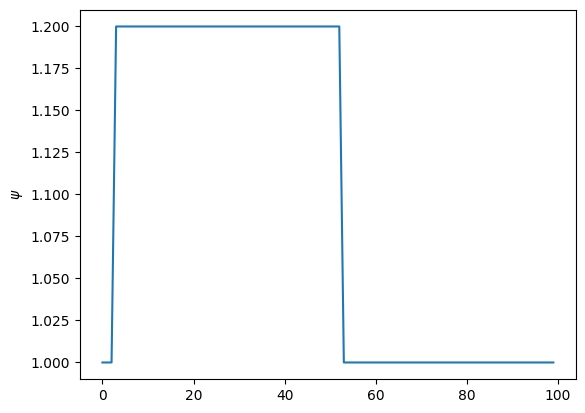

In [8]:
# Design the shock:

# for this example, I am assuming that productivity increases and then
# goes back to the original level.

psi_high = 1.2
Psi_sequence = np.array([psi]*3+
                        [psi_high]*50+
                        [psi]*(T-3-50))
# Check the pattern of the shock
plt.figure()
plt.plot(Psi_sequence)
plt.ylabel('$\psi$')

# Dolo receives a DataFrame with the full future paths for ALL exogenous
# variables. So we create one:
Exog = pd.DataFrame({'R':[R]*T,
                     'tau':[tau]*T,
                     'itc_1':[zeta]*T,
                     'psi':Psi_sequence})

# Examine the first few entries.
Exog.head()
# Note all other variables are left constant.

In [9]:
# Now use the "perfect foresight" dolo solver
response = pf.deterministic_solve(model = QDolo, # Model we are using (in dolo)
                                  shocks = Exog, # Paths for exog. variables 
                                  T=T,           # Total simulation time
                                  s1 = [k0],     # Initial state
                                  verbose=True)

# Response is a DataFrame with the paths of every variable over time.
# It adds information we don't need on the first row. So we delete it
response = response[1:]

# Inspect the first few elements.
response.head()

	> 1 | 0.08584546286337591 | 0
	> 2 | 0.028939741816380926 | 0
	> 3 | 0.005488334466131395 | 0
	> 4 | 0.0002628160877001795 | 0
	> 5 | 6.063950412915631e-07 | 0
> System was solved after iteration 5. Residual=6.063950412915631e-07


,k,i,y,y_k,beta,j,xi,iota,j_i,j_k,lambda_1,q_1,R,tau,itc_1,psi
1,4.298990,0.653092,1.618121,0.124211,0.98,0.005794,0.645708,0.051918,0.051918,-0.006539,1.051918,1.051918,1.020408,0.05,0.0,1.0
2,4.522183,0.702993,1.645375,0.120069,0.98,0.006953,0.695747,0.055454,0.055454,-0.007083,1.055454,1.055454,1.020408,0.05,0.0,1.0
3,4.772958,0.675014,2.009931,0.138966,0.98,0.004095,0.665527,0.041425,0.041425,-0.005000,1.041425,1.041425,1.020408,0.05,0.0,1.2
4,4.970676,0.651641,2.037034,0.135237,0.98,0.002403,0.640964,0.031097,0.031097,-0.003593,1.031097,1.031097,1.020408,0.05,0.0,1.2
5,5.125250,0.632612,2.057724,0.132491,0.98,0.001407,0.621338,0.023430,0.023430,-0.002618,1.023430,1.023430,1.020408,0.05,0.0,1.2


# IMPORTANT

Because of the way the model is implemented, it does not keep track of $\lambda_t$ or $ITC_t$, but  $\lambda_{t+1}$ and $ITC_{t+1}$ instead. 

Thus, lambda_1 in row 1 corresponds to $\lambda_2$. Same with the ITC.

# Plots

Now we can use Qmod to plot the phase diagrams and add the optimal dynamics that we just found.

Text(0.5, 0, 'Time')

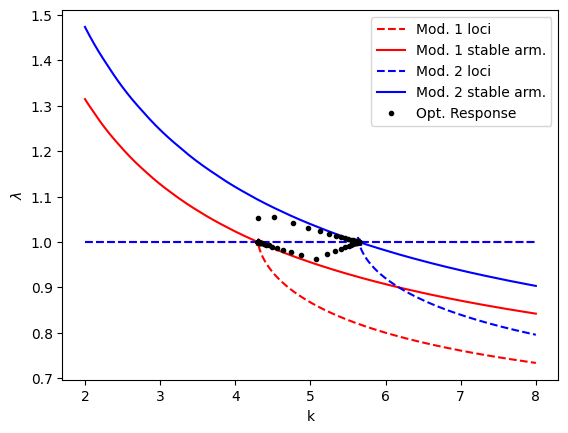

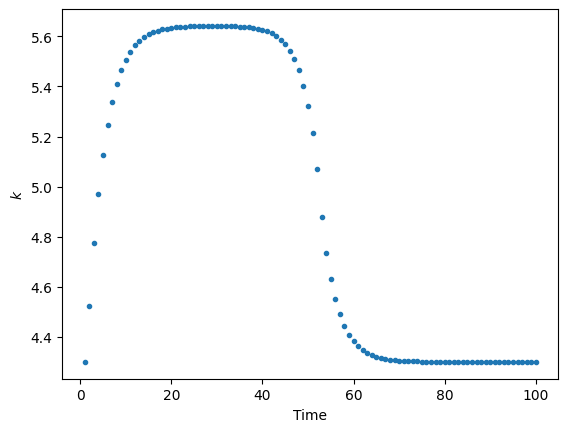

In [10]:
# Draw the two phase diagrams and save them in an object
# to add the plots of dynamics later.

# Copy the initial model, set the higher psi and re-solve
Q_high_psi = deepcopy(Qmodel)
Q_high_psi.psi = psi_high
Q_high_psi.solve()

# Now we draw the phase diagrams of our base model "Qmodel"
# and the new one "Q_high_psi", and store the plot in
# object "ax"
ax = phase_diagrams(mod1 = Qmodel, mod2 = Q_high_psi, k_min = 2, k_max = 8)

# Now we can add the behavior of lambda and k to the diagram.
ax.plot(response.k, response.lambda_1, '.k',label = 'Opt. Response')
plt.legend()
plt.xlabel('k')
plt.ylabel('$\\lambda$')

# New figure for capital dynamics
plt.figure()
plt.plot(response.k,'.')
plt.ylabel('$k$')
plt.xlabel('Time')

,R,tau,itc_1,psi
0,1.020408,0.2,0,1
1,1.020408,0.2,0,1
2,1.020408,0.2,0,1
3,1.020408,0.2,0,1
4,1.020408,0.2,0,1


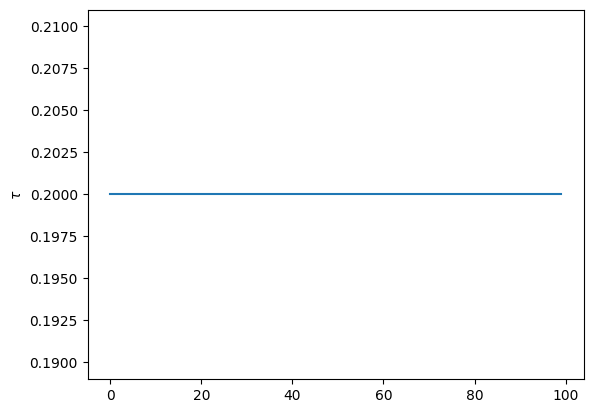

In [11]:
#Q1 Design the shock:

# tau goes up permanently
# does not goes back to the original level.

tau_high = 0.20
Tau_sequence = np.array(
                        [tau_high]*(T))
# Check the pattern of the shock
plt.figure()
plt.plot(Tau_sequence)
plt.ylabel(r'$\tau$')

# Dolo receives a DataFrame with the full future paths for ALL exogenous
# variables. So we create one:
Exog = pd.DataFrame({'R':[R]*T,
                     'tau':Tau_sequence,
                     'itc_1':[zeta]*T,
                     'psi':[psi]*T})

# Examine the first few entries.
Exog.head()
# Note all other variables are left constant.

In [12]:
# Now use the "perfect foresight" dolo solver
response = pf.deterministic_solve(model = QDolo, # Model we are using (in dolo)
                                  shocks = Exog, # Paths for exog. variables 
                                  T=T,           # Total simulation time
                                  s1 = [k0],     # Initial state
                                  verbose=True)

# Response is a DataFrame with the paths of every variable over time.
# It adds information we don't need on the first row. So we delete it
response = response[1:]

# Inspect the first few elements.
response.head()

	> 1 | 0.06035111013995975 | 0
	> 2 | 0.017456709505415446 | 0
	> 3 | 0.0022821837115074572 | 0
	> 4 | 4.6283890327236676e-05 | 0
	> 5 | 1.791119830230059e-08 | 0
> System was solved after iteration 5. Residual=1.791119830230059e-08


,k,i,y,y_k,beta,j,xi,iota,j_i,j_k,lambda_1,q_1,R,tau,itc_1,psi
1,4.298990,0.182338,1.618121,0.124211,0.98,0.007128,0.185677,-0.057586,-0.057586,0.004101,0.942414,0.942414,1.020408,0.2,0.0,1.0
2,4.051429,0.223371,1.586758,0.129246,0.98,0.004078,0.222900,-0.044866,-0.044866,0.003480,0.955134,0.955134,1.020408,0.2,0.0,1.0
3,3.869657,0.252377,1.562903,0.133283,0.98,0.002341,0.249623,-0.034781,-0.034781,0.002873,0.965219,0.965219,1.020408,0.2,0.0,1.0
4,3.735068,0.273197,1.544751,0.136482,0.98,0.001347,0.269053,-0.026856,-0.026856,0.002325,0.973144,0.973144,1.020408,0.2,0.0,1.0
5,3.634758,0.288330,1.530936,0.138994,0.98,0.000777,0.283324,-0.020674,-0.020674,0.001854,0.979326,0.979326,1.020408,0.2,0.0,1.0


Text(0.5, 0, 'Time')

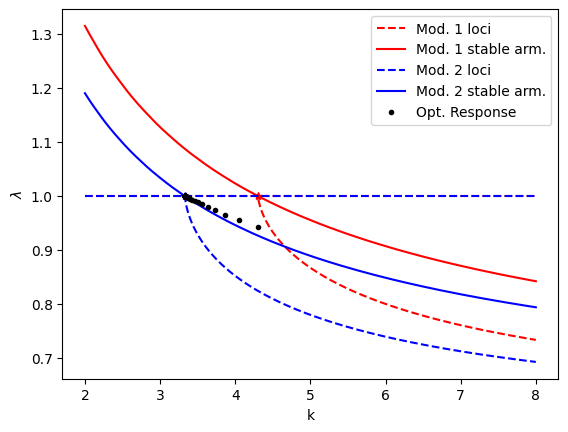

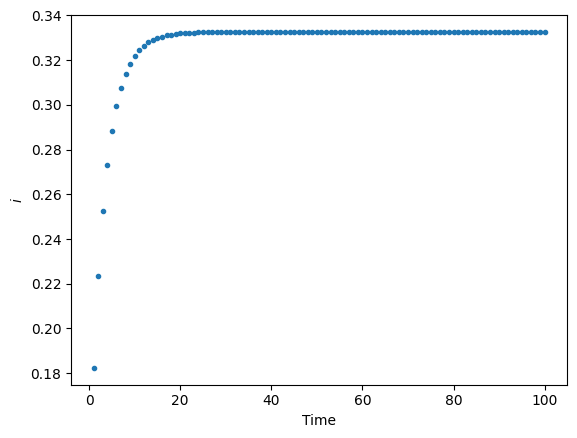

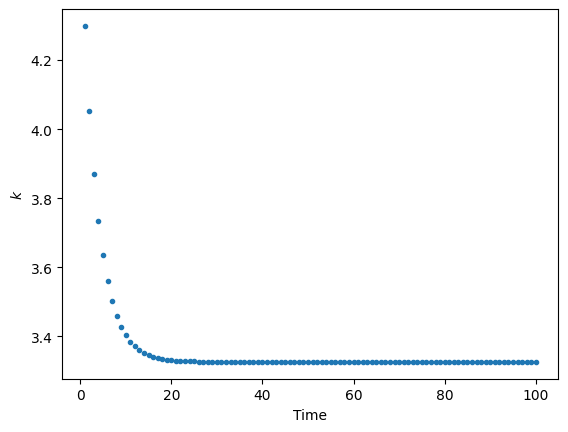

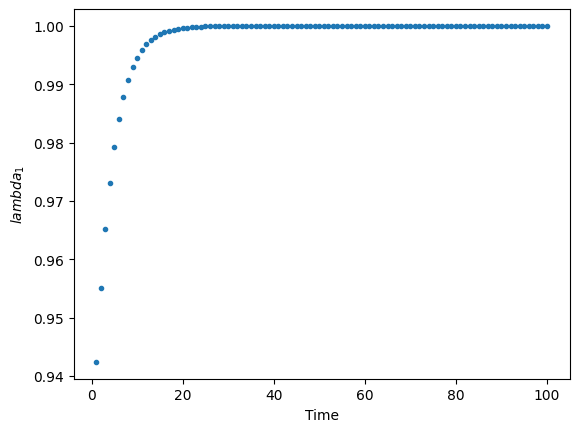

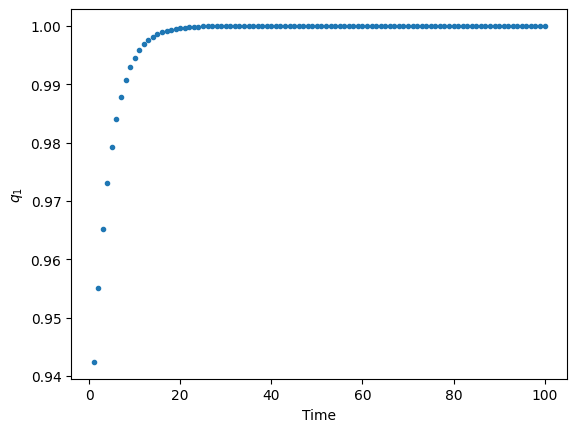

In [13]:
# Draw the two phase diagrams and save them in an object
# to add the plots of dynamics later.

# Copy the initial model, set the higher psi and re-solve
Q_high_tau = deepcopy(Qmodel)
Q_high_tau.tau = tau_high
Q_high_tau.solve()

# Now we draw the phase diagrams of our base model "Qmodel"
# and the new one "Q_high_psi", and store the plot in
# object "ax"
ax = phase_diagrams(mod1 = Qmodel, mod2 = Q_high_tau, k_min = 2, k_max = 8)

# Now we can add the behavior of lambda and k to the diagram.
ax.plot(response.k, response.lambda_1, '.k',label = 'Opt. Response')
plt.legend()
plt.xlabel('k')
plt.ylabel('$\\lambda$')

# New figure for investment dynamics
plt.figure()
plt.plot(response.i,'.')
plt.ylabel('$i$')
plt.xlabel('Time')

# New figure for capital dynamics
plt.figure()
plt.plot(response.k,'.')
plt.ylabel('$k$')
plt.xlabel('Time')

# New figure for share price dynamics
plt.figure()
plt.plot(response.lambda_1,'.')
plt.ylabel('$lambda_1$')
plt.xlabel('Time')

# New figure for q dynamics
plt.figure()
plt.plot(response.q_1,'.')
plt.ylabel('$q_1$')
plt.xlabel('Time')

In [14]:
#intuition: :A higher tax rate reduces the after-tax portion of revenues. In the long run,the after-tax marginal product of capital 
#            must equal the interest rate r.Since the tax bite is larger, the pre-tax marginal product f'(k) must rise to compensate. 
#            A higher marginal product implies a lower capital stock.The fundamental value of holding capital inside the firm falls
#            because the government takes a larger slice of the returns.At the old equilibrium (q=1), the marginal value of capital 
#            is now below its replacement cost. The delta q=0 locus shifts down. Because capital is sticky (cannot drop instantly),
#            the shadow price q and share price λ jump down immediately at t=0.This signal (q<1) tells the firm to stop investing. 
#            Over time, the capital stock depreciates until it becomes scarce enough that its marginal product rises to justify the new tax rate.
           

In [15]:
# Set up the basic features of the simulation

# Total simulation time
T = 100
# Initial level of capital
k0 = Qmodel.kss

,R,tau,itc_1,psi
0,1.020408,0.20,0,1
1,1.020408,0.20,0,1
2,1.020408,0.05,0,1
3,1.020408,0.05,0,1
4,1.020408,0.05,0,1


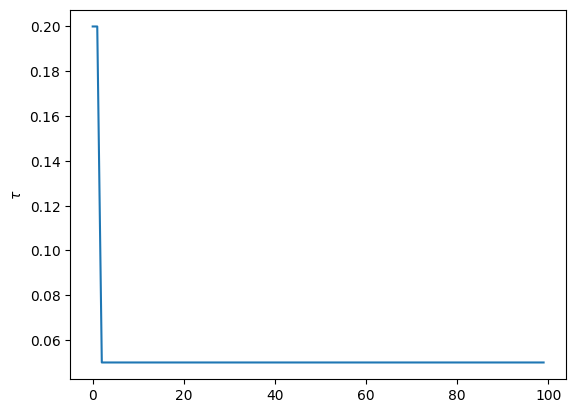

In [16]:
#Q2 Design the shock:
# tau goes up temporarily 
# then goes back to the original level.

tau_high = 0.20
Tau_sequence = np.array([tau_high]*2+
                        [tau]*(T-2))
# Check the pattern of the shock
plt.figure()
plt.plot(Tau_sequence)
plt.ylabel(r'$\tau$')

# Dolo receives a DataFrame with the full future paths for ALL exogenous
# variables. So we create one:
Exog = pd.DataFrame({'R':[R]*T,
                     'tau':Tau_sequence,
                     'itc_1':[zeta]*T,
                     'psi':[psi]*T})

# Examine the first few entries.
Exog.head()
# Note all other variables are left constant.

In [17]:
# Now use the "perfect foresight" dolo solver

response_high = pf.deterministic_solve(model = QDolo, # Model we are using (in dolo)
                                  shocks = Exog, # Paths for exog. variables 
                                  T=T,           # Total simulation time
                                  s1 = [k0],     # Initial state
                                  verbose=True)
print("Initial state row:")
print(response_high.iloc[0])
# Response is a DataFrame with the paths of every variable over time.
# It adds information we don't need on the first row. So we delete it
response_high = response_high[1:]

# Inspect the first few elements.
response_high.head()

	> 1 | 0.08584546283991046 | 0
	> 2 | 0.028939742273841995 | 0
	> 3 | 0.00548833977331642 | 0
	> 4 | 0.0002628161953516228 | 0
	> 5 | 6.06518961165925e-07 | 0
> System was solved after iteration 5. Residual=6.06518961165925e-07
Initial state row:
k                NaN
i                NaN
y                NaN
y_k              NaN
beta        0.980000
j                NaN
xi               NaN
iota             NaN
j_i              NaN
j_k              NaN
lambda_1         NaN
q_1              NaN
R           1.020408
tau         0.200000
itc_1       0.000000
psi         1.000000
Name: 0, dtype: float64


,k,i,y,y_k,beta,j,xi,iota,j_i,j_k,lambda_1,q_1,R,tau,itc_1,psi
1,4.298990,0.368448,1.618121,0.124211,0.98,0.000439,0.361510,-0.014294,-0.014294,0.001327,0.985706,0.985706,1.020408,0.20,0.0,1.0
2,4.237540,0.438319,1.610451,0.125414,0.98,0.000025,0.429577,0.003437,0.003437,-0.000350,1.003437,1.003437,1.020408,0.05,0.0,1.0
3,4.252105,0.436334,1.612276,0.125126,0.98,0.000015,0.427621,0.002616,0.002616,-0.000265,1.002616,1.002616,1.020408,0.05,0.0,1.0
4,4.263228,0.434813,1.613666,0.124908,0.98,0.000008,0.426125,0.001992,0.001992,-0.000201,1.001992,1.001992,1.020408,0.05,0.0,1.0
5,4.271718,0.433650,1.614726,0.124741,0.98,0.000005,0.424982,0.001517,0.001517,-0.000153,1.001517,1.001517,1.020408,0.05,0.0,1.0


In [18]:
# Now use the "perfect foresight" dolo solver

response_high_o = pf.deterministic_solve(model = QDolo_h, # Model we are using (in dolo)
                                  shocks = Exog, # Paths for exog. variables 
                                  T=T,           # Total simulation time
                                  s1 = [k0],     # Initial state
                                  verbose=True)
print("Initial state row:")
print(response_high_o.iloc[0])
# Response is a DataFrame with the paths of every variable over time.
# It adds information we don't need on the first row. So we delete it
response_high_o = response_high_o[1:]

# Inspect the first few elements.
response_high_o.head()

	> 1 | 0.0933783835096702 | 0
	> 2 | 0.03202717406471567 | 0
	> 3 | 0.006034022483635937 | 0
	> 4 | 0.000266004987335422 | 0
	> 5 | 4.843333695214724e-07 | 0
> System was solved after iteration 5. Residual=4.843333695214724e-07
Initial state row:
k                NaN
i                NaN
y                NaN
y_k              NaN
beta        0.980000
j                NaN
xi               NaN
iota             NaN
j_i              NaN
j_k              NaN
lambda_1         NaN
q_1              NaN
R           1.020408
tau         0.200000
itc_1       0.000000
psi         1.000000
Name: 0, dtype: float64


,k,i,y,y_k,beta,j,xi,iota,j_i,j_k,lambda_1,q_1,R,tau,itc_1,psi
1,4.298990,0.415615,1.618121,0.124211,0.98,1.186499e-04,0.407419,-0.003323,-0.016613,0.001634,0.983387,0.983387,1.020408,0.20,0.0,1.0
2,4.284706,0.430041,1.616345,0.124488,0.98,1.439601e-06,0.421442,0.000367,0.001833,-0.000184,1.001833,1.001833,1.020408,0.05,0.0,1.0
3,4.286277,0.430026,1.616540,0.124457,0.98,1.140181e-06,0.421426,0.000326,0.001631,-0.000163,1.001631,1.001631,1.020408,0.05,0.0,1.0
4,4.287675,0.430012,1.616714,0.124430,0.98,9.030342e-07,0.421413,0.000290,0.001451,-0.000145,1.001451,1.001451,1.020408,0.05,0.0,1.0
5,4.288920,0.430000,1.616869,0.124406,0.98,7.152105e-07,0.421400,0.000258,0.001291,-0.000129,1.001291,1.001291,1.020408,0.05,0.0,1.0


Text(0.5, 0, 'Time')

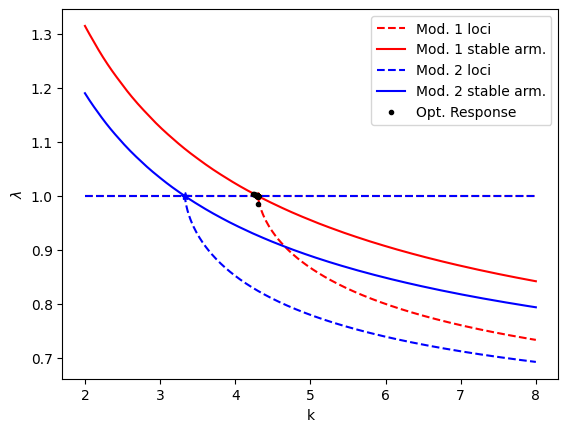

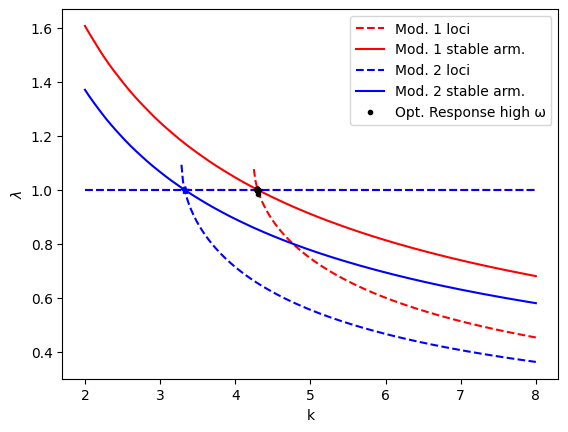

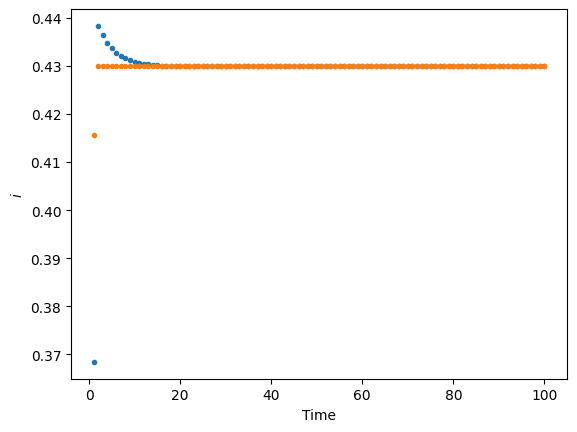

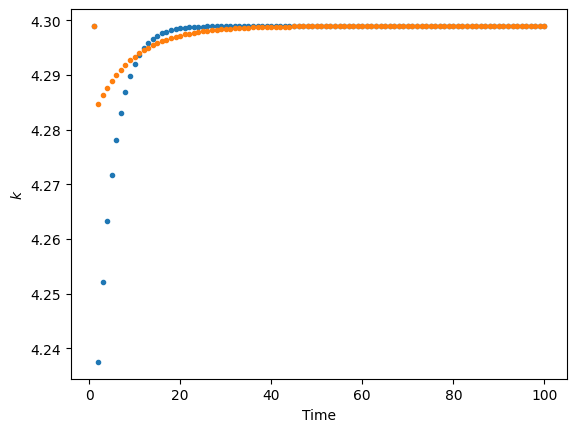

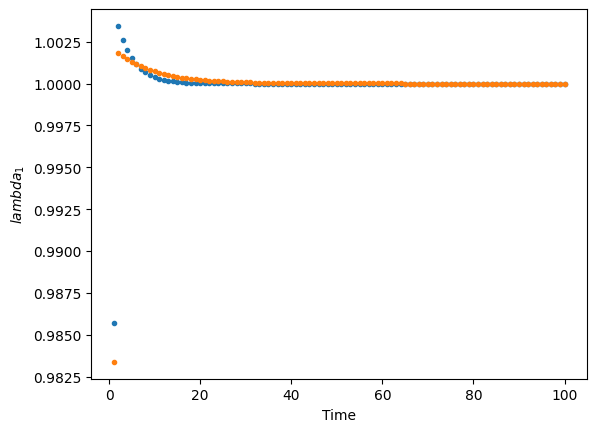

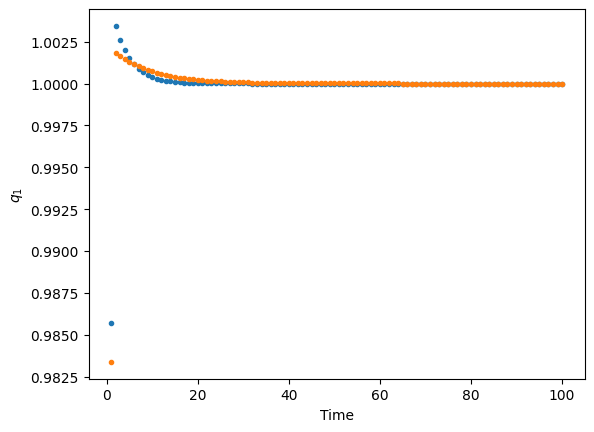

In [19]:
# Draw the two phase diagrams and save them in an object
# to add the plots of dynamics later.

# Copy the initial model, set the higher psi and re-solve
Q_high_tau = deepcopy(Qmodel)
Q_high_tau.tau = tau_high
Q_high_tau.solve()

Q_high_omega = deepcopy(Qmodel_2_h)
Q_high_omega.tau = tau_high
Q_high_omega.solve()

# Now we draw the phase diagrams of our base model "Qmodel"
# and the new one "Q_high_psi", and store the plot in
# object "ax"
ax = phase_diagrams(mod1 = Qmodel, mod2 = Q_high_tau, k_min = 2, k_max = 8)

# Now we can add the behavior of lambda and k to the diagram.
ax.plot(response_high.k, response_high.lambda_1, '.k', label='Opt. Response')

plt.legend()
plt.xlabel('k')
plt.ylabel('$\\lambda$')

ax = phase_diagrams(mod1 = Qmodel_2_h, mod2 = Q_high_omega, k_min = 2, k_max = 8)

# Now we can add the behavior of lambda and k to the diagram.
ax.plot(response_high_o.k, response_high_o.lambda_1, '.k', label='Opt. Response high ω')

plt.legend()
plt.xlabel('k')
plt.ylabel('$\\lambda$')

# New figure for investment dynamics
plt.figure()
plt.plot(response_high.i,'.')
plt.plot(response_high_o.i,'.')
plt.ylabel('$i$')
plt.xlabel('Time')

# New figure for capital dynamics
plt.figure()
plt.plot(response_high.k,'.')
plt.plot(response_high_o.k,'.')
plt.ylabel('$k$')
plt.xlabel('Time')

# New figure for share price dynamics
plt.figure()
plt.plot(response_high.lambda_1,'.')
plt.plot(response_high_o.lambda_1,'.')
plt.ylabel('$lambda_1$')
plt.xlabel('Time')

# New figure for q dynamics
plt.figure()
plt.plot(response_high.q_1,'.')
plt.plot(response_high_o.q_1,'.')
plt.ylabel('$q_1$')
plt.xlabel('Time')

In [20]:
#intuition: Since the tax increase is temporary, the long-run steady state remains unchanged; the economy must eventually return to its 
#           original position. During the high-tax period, holding capital is less profitable, causing the shadow price q to jump down 
#           immediately. Firms respond by reducing investment to shrink their capital stock, but because they know relief is coming in two years, 
#           the drop in q is smaller than it would be for a permanent shock. If adjustment costs are low, firms react aggressively by selling off 
#           capital (a wide loop in the phase diagram); if adjustment costs are high, firms mostly "ride out" the temporary pain, keeping capital 
#           constant while the asset price absorbs the shock (a vertical drop in the phase diagram).


,R,tau,itc_1,psi
0,1.020408,0.2,0,1
1,1.020408,0.2,0,1
2,1.020408,0.2,0,1
3,1.020408,0.1,0,1
4,1.020408,0.1,0,1


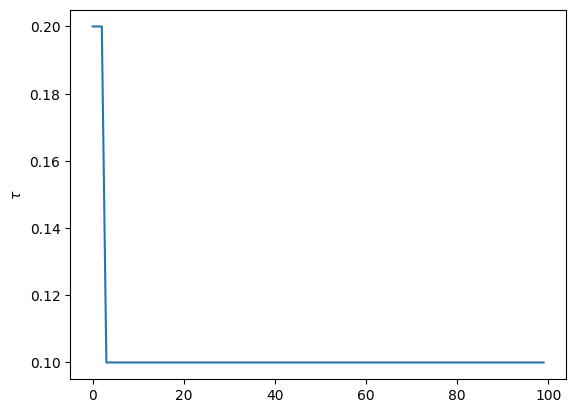

In [21]:
#Q3 Design the shock:
# Set up the basic features of the simulation

# Total simulation time
T = 100
# Initial level of capital
k0 = Qmodel_3.kss

## Dynamic response example: changes in productivity.

# tau announce going down early 
# then goes down permanently after 3 year.

tau_high = 0.20
tau_low = 0.10
Tau_sequence = np.array([tau_high]*3+
                        [tau_low]*(T-3))
# Check the pattern of the shock
plt.figure()
plt.plot(Tau_sequence)
plt.ylabel(r'$\tau$')

# Dolo receives a DataFrame with the full future paths for ALL exogenous
# variables. So we create one:
Exog = pd.DataFrame({'R':[R]*T,
                     'tau':Tau_sequence,
                     'itc_1':[zeta]*T,
                     'psi':[psi]*T})

# Examine the first few entries.
Exog.head()
# Note all other variables are left constant.

In [22]:
# Now use the "perfect foresight" dolo solver

response_high = pf.deterministic_solve(model = QDolo, # Model we are using (in dolo)
                                  shocks = Exog, # Paths for exog. variables 
                                  T=T,           # Total simulation time
                                  s1 = [k0],     # Initial state
                                  verbose=True)
print("Initial state row:")
print(response_high.iloc[0])
# Response is a DataFrame with the paths of every variable over time.
# It adds information we don't need on the first row. So we delete it
response_high = response_high[1:]

# Inspect the first few elements.
response_high.head()

	> 1 | 0.07665319946904914 | 0
	> 2 | 0.024732563429619603 | 0
	> 3 | 0.004252707323376015 | 0
	> 4 | 0.00016453299276242284 | 0
	> 5 | 2.478490713775372e-07 | 0
> System was solved after iteration 5. Residual=2.478490713775372e-07
Initial state row:
k                NaN
i                NaN
y                NaN
y_k              NaN
beta        0.980000
j                NaN
xi               NaN
iota             NaN
j_i              NaN
j_k              NaN
lambda_1         NaN
q_1              NaN
R           1.020408
tau         0.200000
itc_1       0.000000
psi         1.000000
Name: 0, dtype: float64


,k,i,y,y_k,beta,j,xi,iota,j_i,j_k,lambda_1,q_1,R,tau,itc_1,psi
1,3.326389,0.414210,1.486795,0.147500,0.98,0.001000,0.406906,0.024522,0.024522,-0.002753,1.024522,1.024522,1.020408,0.2,0.0,1.0
2,3.407960,0.431474,1.498729,0.145125,0.98,0.001206,0.424027,0.026608,0.026608,-0.003015,1.026608,1.026608,1.020408,0.2,0.0,1.0
3,3.498638,0.457218,1.511773,0.142594,0.98,0.001647,0.449688,0.030685,0.030685,-0.003539,1.030685,1.030685,1.020408,0.1,0.0,1.0
4,3.605992,0.443981,1.526927,0.139736,0.98,0.000964,0.436046,0.023123,0.023123,-0.002580,1.023123,1.023123,1.020408,0.1,0.0,1.0
5,3.689374,0.433399,1.538489,0.137612,0.98,0.000563,0.425283,0.017472,0.017472,-0.001900,1.017472,1.017472,1.020408,0.1,0.0,1.0


In [23]:
# Now use the "perfect foresight" dolo solver

response_high_o = pf.deterministic_solve(model = QDolo_h, # Model we are using (in dolo)
                                  shocks = Exog, # Paths for exog. variables 
                                  T=T,           # Total simulation time
                                  s1 = [k0],     # Initial state
                                  verbose=True)
print("Initial state row:")
print(response_high_o.iloc[0])
# Response is a DataFrame with the paths of every variable over time.
# It adds information we don't need on the first row. So we delete it
response_high_o = response_high_o[1:]

# Inspect the first few elements.
response_high_o.head()

	> 1 | 0.08174927098455387 | 0
	> 2 | 0.026744998644654405 | 0
	> 3 | 0.004572260013283813 | 0
	> 4 | 0.00016455555418781742 | 0
	> 5 | 2.0021270308312467e-07 | 0
> System was solved after iteration 5. Residual=2.0021270308312467e-07
Initial state row:
k                NaN
i                NaN
y                NaN
y_k              NaN
beta        0.980000
j                NaN
xi               NaN
iota             NaN
j_i              NaN
j_k              NaN
lambda_1         NaN
q_1              NaN
R           1.020408
tau         0.200000
itc_1       0.000000
psi         1.000000
Name: 0, dtype: float64


,k,i,y,y_k,beta,j,xi,iota,j_i,j_k,lambda_1,q_1,R,tau,itc_1,psi
1,3.326389,0.383905,1.486795,0.147500,0.98,0.001975,0.378163,0.015412,0.077060,-0.008300,1.077060,1.077060,1.020408,0.2,0.0,1.0
2,3.377655,0.391289,1.494318,0.145996,0.98,0.002120,0.385542,0.015846,0.079232,-0.008551,1.079232,1.079232,1.020408,0.2,0.0,1.0
3,3.431179,0.399830,1.502091,0.144466,0.98,0.002343,0.394130,0.016529,0.082643,-0.008947,1.082643,1.082643,1.020408,0.1,0.0,1.0
4,3.487891,0.399699,1.510239,0.142888,0.98,0.001858,0.393526,0.014596,0.072981,-0.007831,1.072981,1.072981,1.020408,0.1,0.0,1.0
5,3.538801,0.399535,1.517478,0.141508,0.98,0.001473,0.392987,0.012901,0.064506,-0.006867,1.064506,1.064506,1.020408,0.1,0.0,1.0


Text(0.5, 0, 'Time')

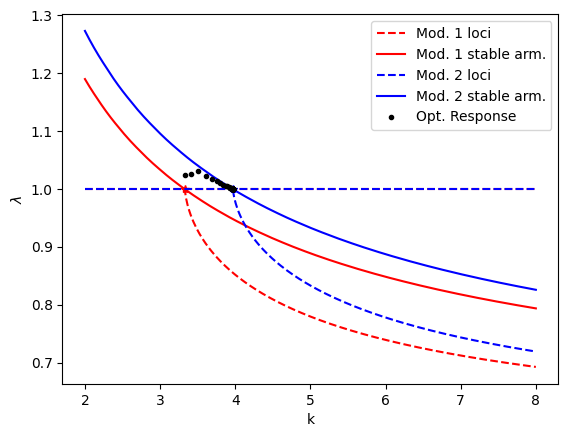

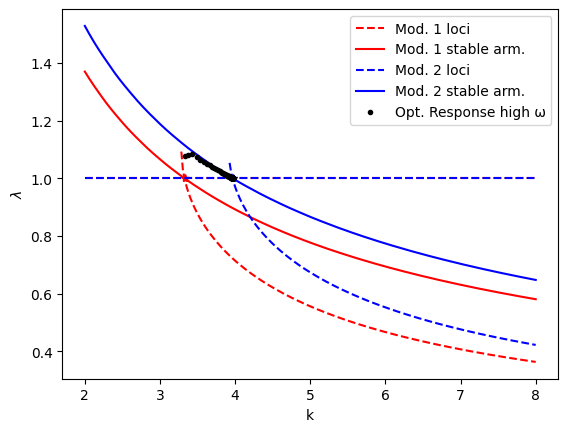

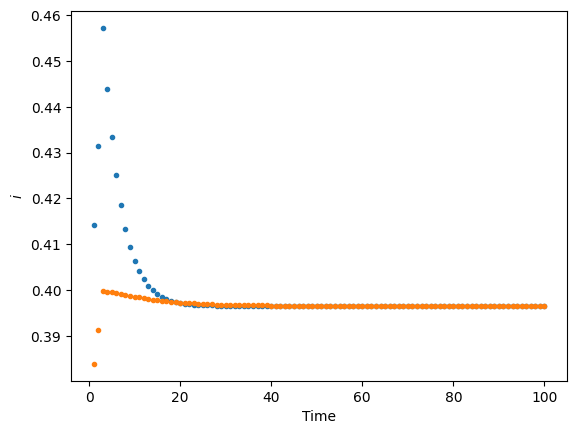

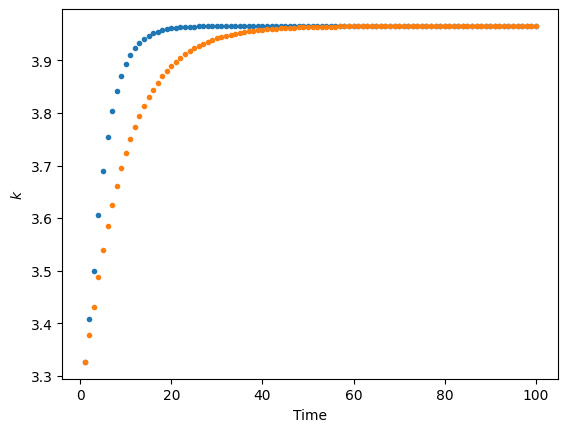

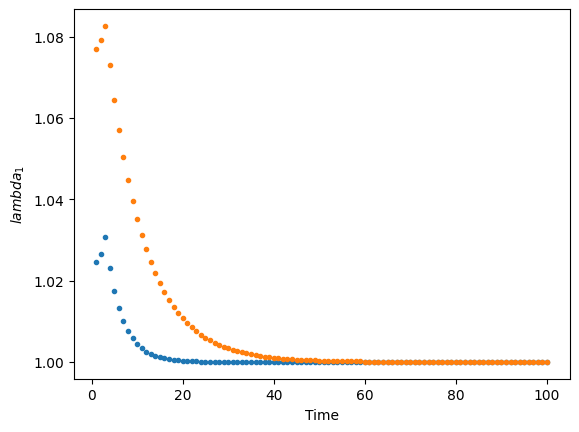

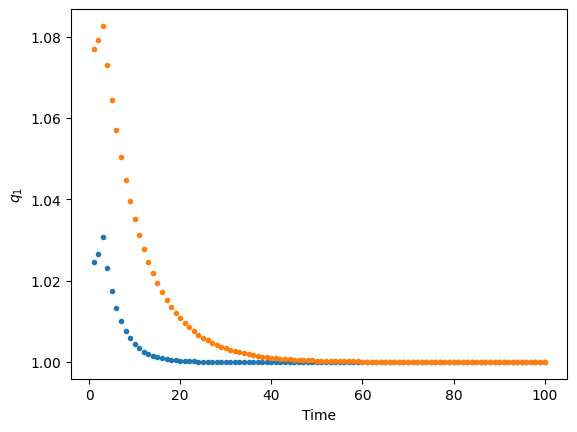

In [25]:
# Draw the two phase diagrams and save them in an object
# to add the plots of dynamics later.

# Copy the initial model, set the higher tau and re-solve
Q_low_tau = deepcopy(Qmodel_3)
Q_low_tau.tau = tau_low
Q_low_tau.solve()

Q_high_omega = deepcopy(Qmodel_3_h)
Q_high_omega.tau = tau_low
Q_high_omega.solve()

# Now we draw the phase diagrams of our base model "Qmodel"
# and the new one "Q_high_psi", and store the plot in
# object "ax"
ax = phase_diagrams(mod1 = Qmodel_3, mod2 = Q_low_tau, k_min = 2, k_max = 8)

# Now we can add the behavior of lambda and k to the diagram.
ax.plot(response_high.k, response_high.lambda_1, '.k', label='Opt. Response')

plt.legend()
plt.xlabel('k')
plt.ylabel('$\\lambda$')

ax = phase_diagrams(mod1 = Qmodel_3_h, mod2 = Q_high_omega, k_min = 2, k_max = 8)

# Now we can add the behavior of lambda and k to the diagram.
ax.plot(response_high_o.k, response_high_o.lambda_1, '.k', label='Opt. Response high ω')

plt.legend()
plt.xlabel('k')
plt.ylabel('$\\lambda$')

# New figure for investment dynamics
plt.figure()
plt.plot(response_high.i,'.')
plt.plot(response_high_o.i,'.')
plt.ylabel('$i$')
plt.xlabel('Time')

# New figure for capital dynamics
plt.figure()
plt.plot(response_high.k,'.')
plt.plot(response_high_o.k,'.')
plt.ylabel('$k$')
plt.xlabel('Time')

# New figure for share price dynamics
plt.figure()
plt.plot(response_high.lambda_1,'.')
plt.plot(response_high_o.lambda_1,'.')
plt.ylabel('$lambda_1$')
plt.xlabel('Time')

# New figure for q dynamics
plt.figure()
plt.plot(response_high.q_1,'.')
plt.plot(response_high_o.q_1,'.')
plt.ylabel('$q_1$')
plt.xlabel('Time')

In [ ]:
#intuition: The announcement of a future tax cut immediately raises the expected future profitability of capital, causing the 
#           shadow price q to jump up at t=0 ("news effect") even though taxes are still high today. Firms start investing 
#           immediately because convex adjustment costs make it cheaper to build capital gradually over three years rather than 
#           rushing to build it all when the cut is implemented. This smoothing motive drives capital accumulation during the transition. 
#           At the moment of implementation (t=3), there is no second jump in the share price (no arbitrage), and the economy lands smoothly
#           on the new saddle path to converge to the higher steady state.

In [ ]:
#Q4 intuition:  A retroactive tax applies only to profits that have already been earned, which acts as a lump-sum levy on the firm's current 
#               wealth (lowering Average Q). However, in the q-model, investment decisions are driven exclusively by Marginal q—the present 
#               value of future returns on new capital. Since a tax on the past does not alter the marginal cost or marginal benefit of buying 
#               a new machine today, it has zero effect on investment incentives or the capital stock. This contrasts sharply with the Investment
#               Tax Credit (ITC), which directly lowers the marginal cost of new capital and powerfully stimulates investment.

In [ ]:
#Q5 intuition: If firms can shift reported profits between years at a convex cost, they can effectively smooth out the tax shock, paying an 
#              average "effective" tax rate rather than the volatile statutory rate. This ability to adjust "paper profits" acts as a buffer, 
#              reducing the pressure to adjust "real capital." Consequently, the immediate drop in q and investment at the start of a tax hike
#              will be smaller (dampened), as firms use accounting maneuvers to absorb some of the shock, mimicking the dynamics of an economy 
#              with very high physical adjustment costs.